In [36]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map, real_amplitudes, z_feature_map
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA 
from qiskit_aer import AerSimulator
from sklearn.model_selection import train_test_split

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [37]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 1000    # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 6   # Features dimension

# Optimization
MAXITER    = 1000     # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER) 

# Noise 
USE_NOISE = False 
NOISE_RATE = 0.02
# ──────────────────────────────────────────────────────────────────────────────
REUPLOAD_SHOTS = 2048


In [38]:
if USE_NOISE:
    print("Construction du simulateur BRUITÉ...")
    nm = NoiseModel()
    # Erreur sur les portes simples (1 qubit)
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ['u', 'h', 'ry', 'rz'])
    # Erreur sur l'intrication (2 qubits) - on met souvent 5x plus
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    
    # On crée le backend (ton ancien AerSimulator)
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    # On l'enveloppe pour le rendre compatible VQC
    sampler = Sampler(backend)
else:
    print("-> Mode IDÉAL")
    sampler = Sampler(AerSimulator())

-> Mode IDÉAL


In [39]:
def generate_nsphere_data(n_samples, n_dim, radius=None):
    # Génération de points entre -1 et 1
    X = np.random.uniform(-1, 1, (n_samples, n_dim))    
    # Le rayon par défaut est choisi pour équilibrer les classes
    if radius is None:
        radius = np.sqrt(n_dim / 3) 
        
    # Calcul de la norme euclidienne au carré
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    
    return X, y, radius



## Entrainement d'un VQC sur différentes dimensions

In [40]:
all_accuracy = []
for dim in range(2, N_DIM + 1):
    X, y,_ = generate_nsphere_data(n, dim)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ZZFeatureMap est excellente pour les frontières non-linéaires (sphères)
    feature_map = z_feature_map(feature_dimension=dim,reps=2, entanglement='linear')

    # RealAmplitudes avec plus de couches et intrication circulaire 
    ansatz = real_amplitudes(num_qubits=dim, reps=3, entanglement='circular')

    sampler = Sampler(AerSimulator())

    optimizer = COBYLA(maxiter=1000)

    cost_history = []
    def callback(weights, loss):
        cost_history.append(loss)
        print(f"Iteration {len(cost_history)}: Loss = {loss:.4f}")

    # 5. Création et Entraînement du VQC
    vqc = VQC(
        sampler=sampler,
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback
    )



    print(f"Entraînement sur {dim} features en cours...")
    vqc.fit(X_train, y_train)

    # 6. Résultats
    accuracy = vqc.score(X_test, y_test)
    print(f"Précision pour {dim} features: {accuracy:.4f}")
    all_accuracy.append(accuracy)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Entraînement sur 2 features en cours...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Précision pour 2 features: 0.8250
Entraînement sur 3 features en cours...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Précision pour 3 features: 0.9500
Entraînement sur 4 features en cours...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Précision pour 4 features: 0.8850
Entraînement sur 5 features en cours...


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Précision pour 5 features: 0.8300
Entraînement sur 6 features en cours...
Précision pour 6 features: 0.7350


# Réseau de Neurones Classique

In [41]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
# Configuration d'un petit réseau (2 couches de 10 neurones)
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10), 
    max_iter=500, 
    random_state=42
)

all_acc = []
for dim in range(2, N_DIM + 1):
    X, y,_ = generate_nsphere_data(n, dim)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    mlp.fit(X_train, y_train)

# 3. Prédiction et Score
    y_pred_mlp = mlp.predict(X_test)
    acc_mlp = accuracy_score(y_test, y_pred_mlp)
    all_acc.append(acc_mlp)
    print(f"Précision Réseau de Neurones Classique en {dim} dimension: {acc_mlp * 100:.2f}%")
    



/home/nils/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Précision Réseau de Neurones Classique en 2 dimension: 97.50%


/home/nils/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Précision Réseau de Neurones Classique en 3 dimension: 93.50%


/home/nils/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Précision Réseau de Neurones Classique en 4 dimension: 87.00%


/home/nils/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Précision Réseau de Neurones Classique en 5 dimension: 86.50%
Précision Réseau de Neurones Classique en 6 dimension: 85.50%


/home/nils/anaconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


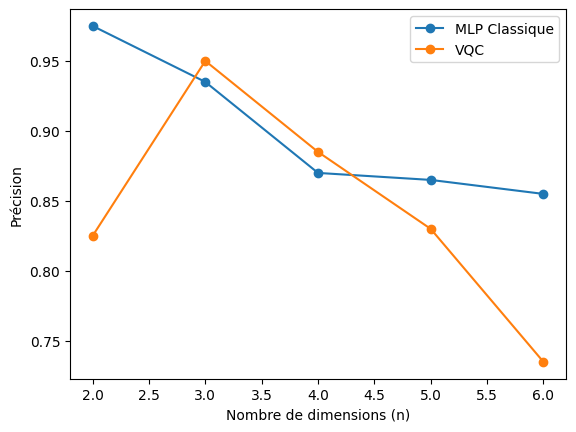

In [42]:
plt.figure()
plt.plot(range(2, N_DIM + 1), all_acc, marker='o', label='MLP Classique')
plt.plot(range(2, N_DIM + 1), all_accuracy, marker='o', label='VQC')
plt.xlabel('Nombre de dimensions (n)')
plt.ylabel('Précision')
plt.legend()
plt.show()